# Career Recommendation System — Exploratory Analysis

In [3]:
import sys
sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from training.data_loader import load_train,load_test

train_df = load_train()
test_df = load_test()
print(f"Training DataFrame shape: {train_df.shape}")
print(f"Testing DataFrame shape: {test_df.shape}")

Training DataFrame shape: (5232, 4)
Testing DataFrame shape: (1194, 4)


## Target Distribution

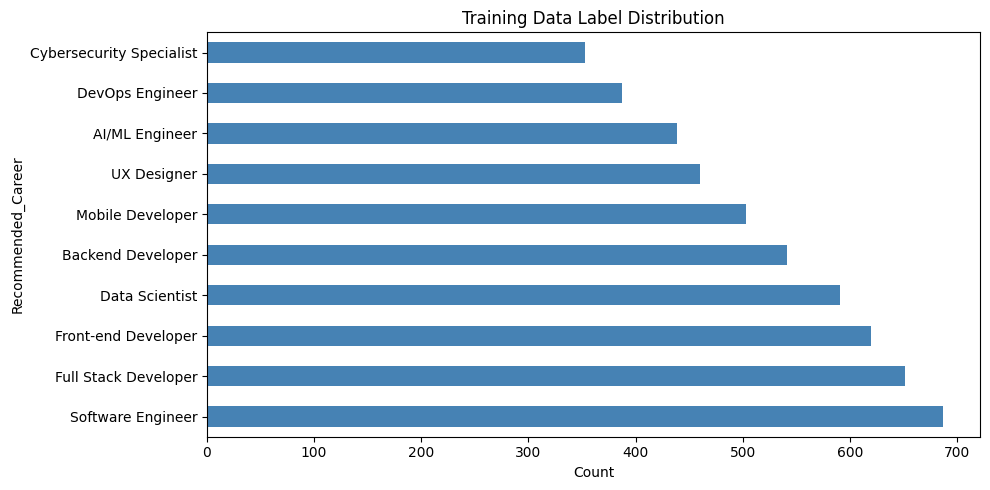

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
train_df['Recommended_Career'].value_counts().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Training Data Label Distribution')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

## Education Distribution

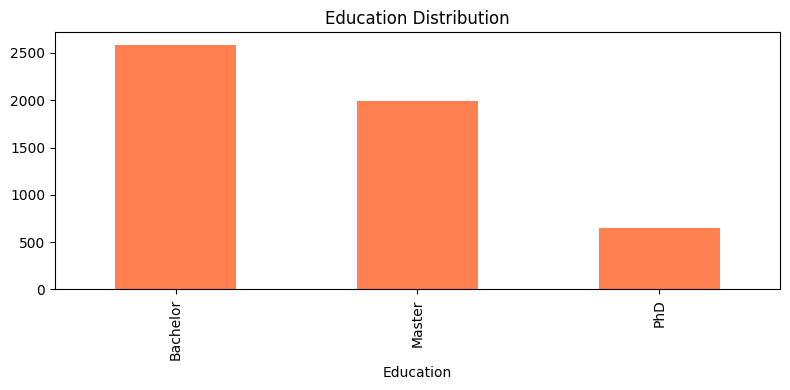

In [6]:
train_df['Education'].value_counts().plot(kind='bar', figsize=(8, 4), color='coral')
plt.title('Education Distribution')
plt.tight_layout()
plt.show()

## Top Skills

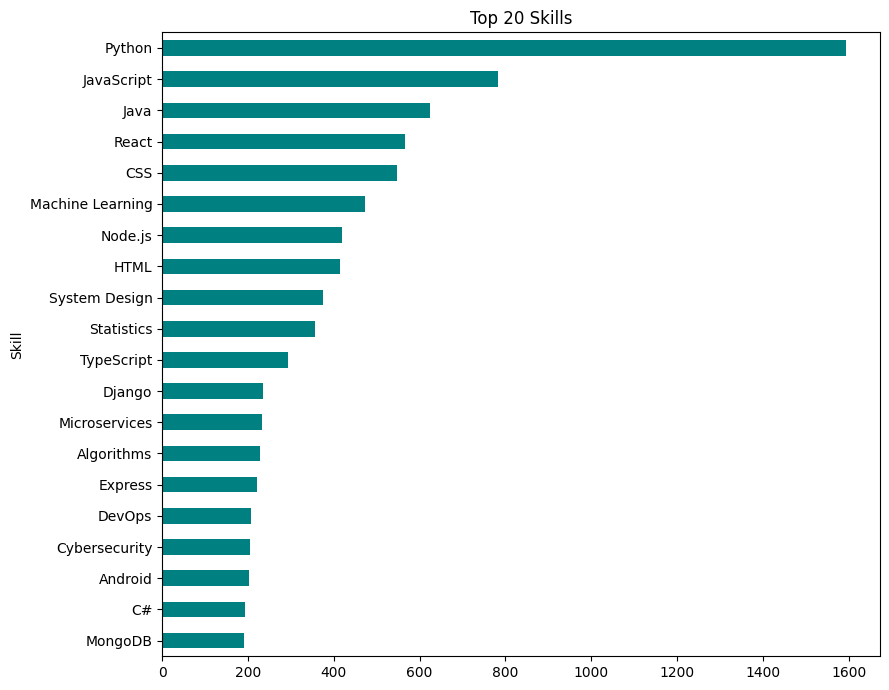

In [7]:
from collections import Counter

all_skills = [s.strip() for row in train_df['Skills'] for s in str(row).split(';')]
skill_counts = Counter(all_skills).most_common(20)
skills_df = pd.DataFrame(skill_counts, columns=['Skill', 'Count'])

skills_df.plot(kind='barh', x='Skill', y='Count', figsize=(9, 7), legend=False, color='teal')
plt.title('Top 20 Skills')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model Comparison

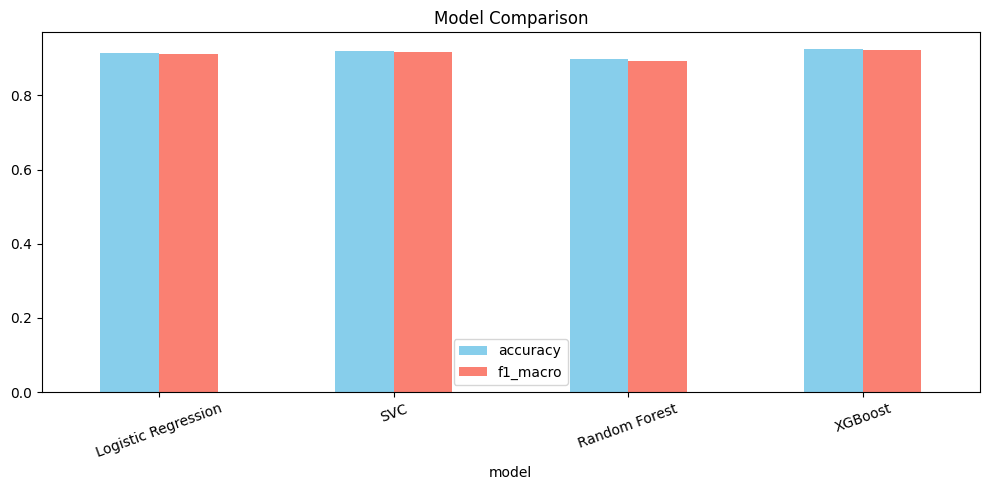

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Logistic Regression,0.9137,0.9119,0.9128,0.9120
1,SVC,0.9196,0.9170,0.9185,0.9174
2,Random Forest,0.8978,0.8935,0.8952,0.8933
3,XGBoost,0.9238,0.9218,0.9224,0.9218


In [11]:
comparison = pd.read_csv('../data/artifacts/model_comparison.csv')
comparison.set_index('model')[['accuracy', 'f1_macro']].plot(kind='bar', figsize=(10, 5), color=['skyblue', 'salmon'])
plt.title('Model Comparison')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
comparison

## Best Model Parameters

Model Evaluation Metrics:


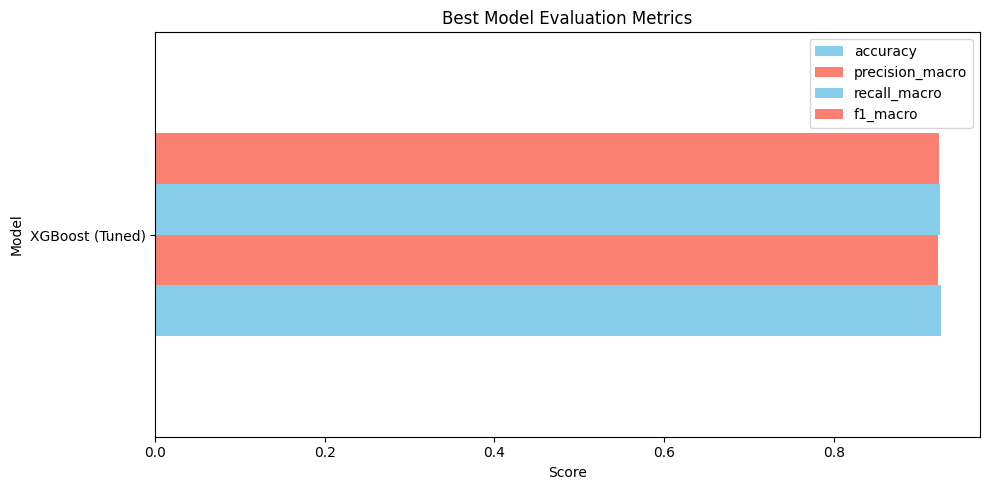


Hyperparameter Tuning Results:
Model: XGBoost
Best Parameters:
  subsample: 0.9
  n_estimators: 200
  min_child_weight: 1
  max_depth: 5
  learning_rate: 0.2
  colsample_bytree: 0.6


In [20]:
import json


with open('../data/artifacts/metrics.json', 'r') as f:
    model_results = json.load(f)

with open('../data/artifacts/tuning_results.json', 'r') as f:
    tuning_results = json.load(f)

print("Model Evaluation Metrics:")
model_results_df = pd.DataFrame([model_results])

model_results_df.set_index('model').plot(kind='barh', figsize=(10, 5), color=['skyblue', 'salmon'])
plt.title('Best Model Evaluation Metrics')
plt.xlabel('Score')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

print("\nHyperparameter Tuning Results:")
tuning_results_df = pd.DataFrame([tuning_results])
#Display in structured table format

for index, row in tuning_results_df.iterrows():
    print(f"Model: {row['model']}")
    print("Best Parameters:")
    for param, value in row['best_params'].items():
        print(f"  {param}: {value}")


## Best Model Confusion Matrix

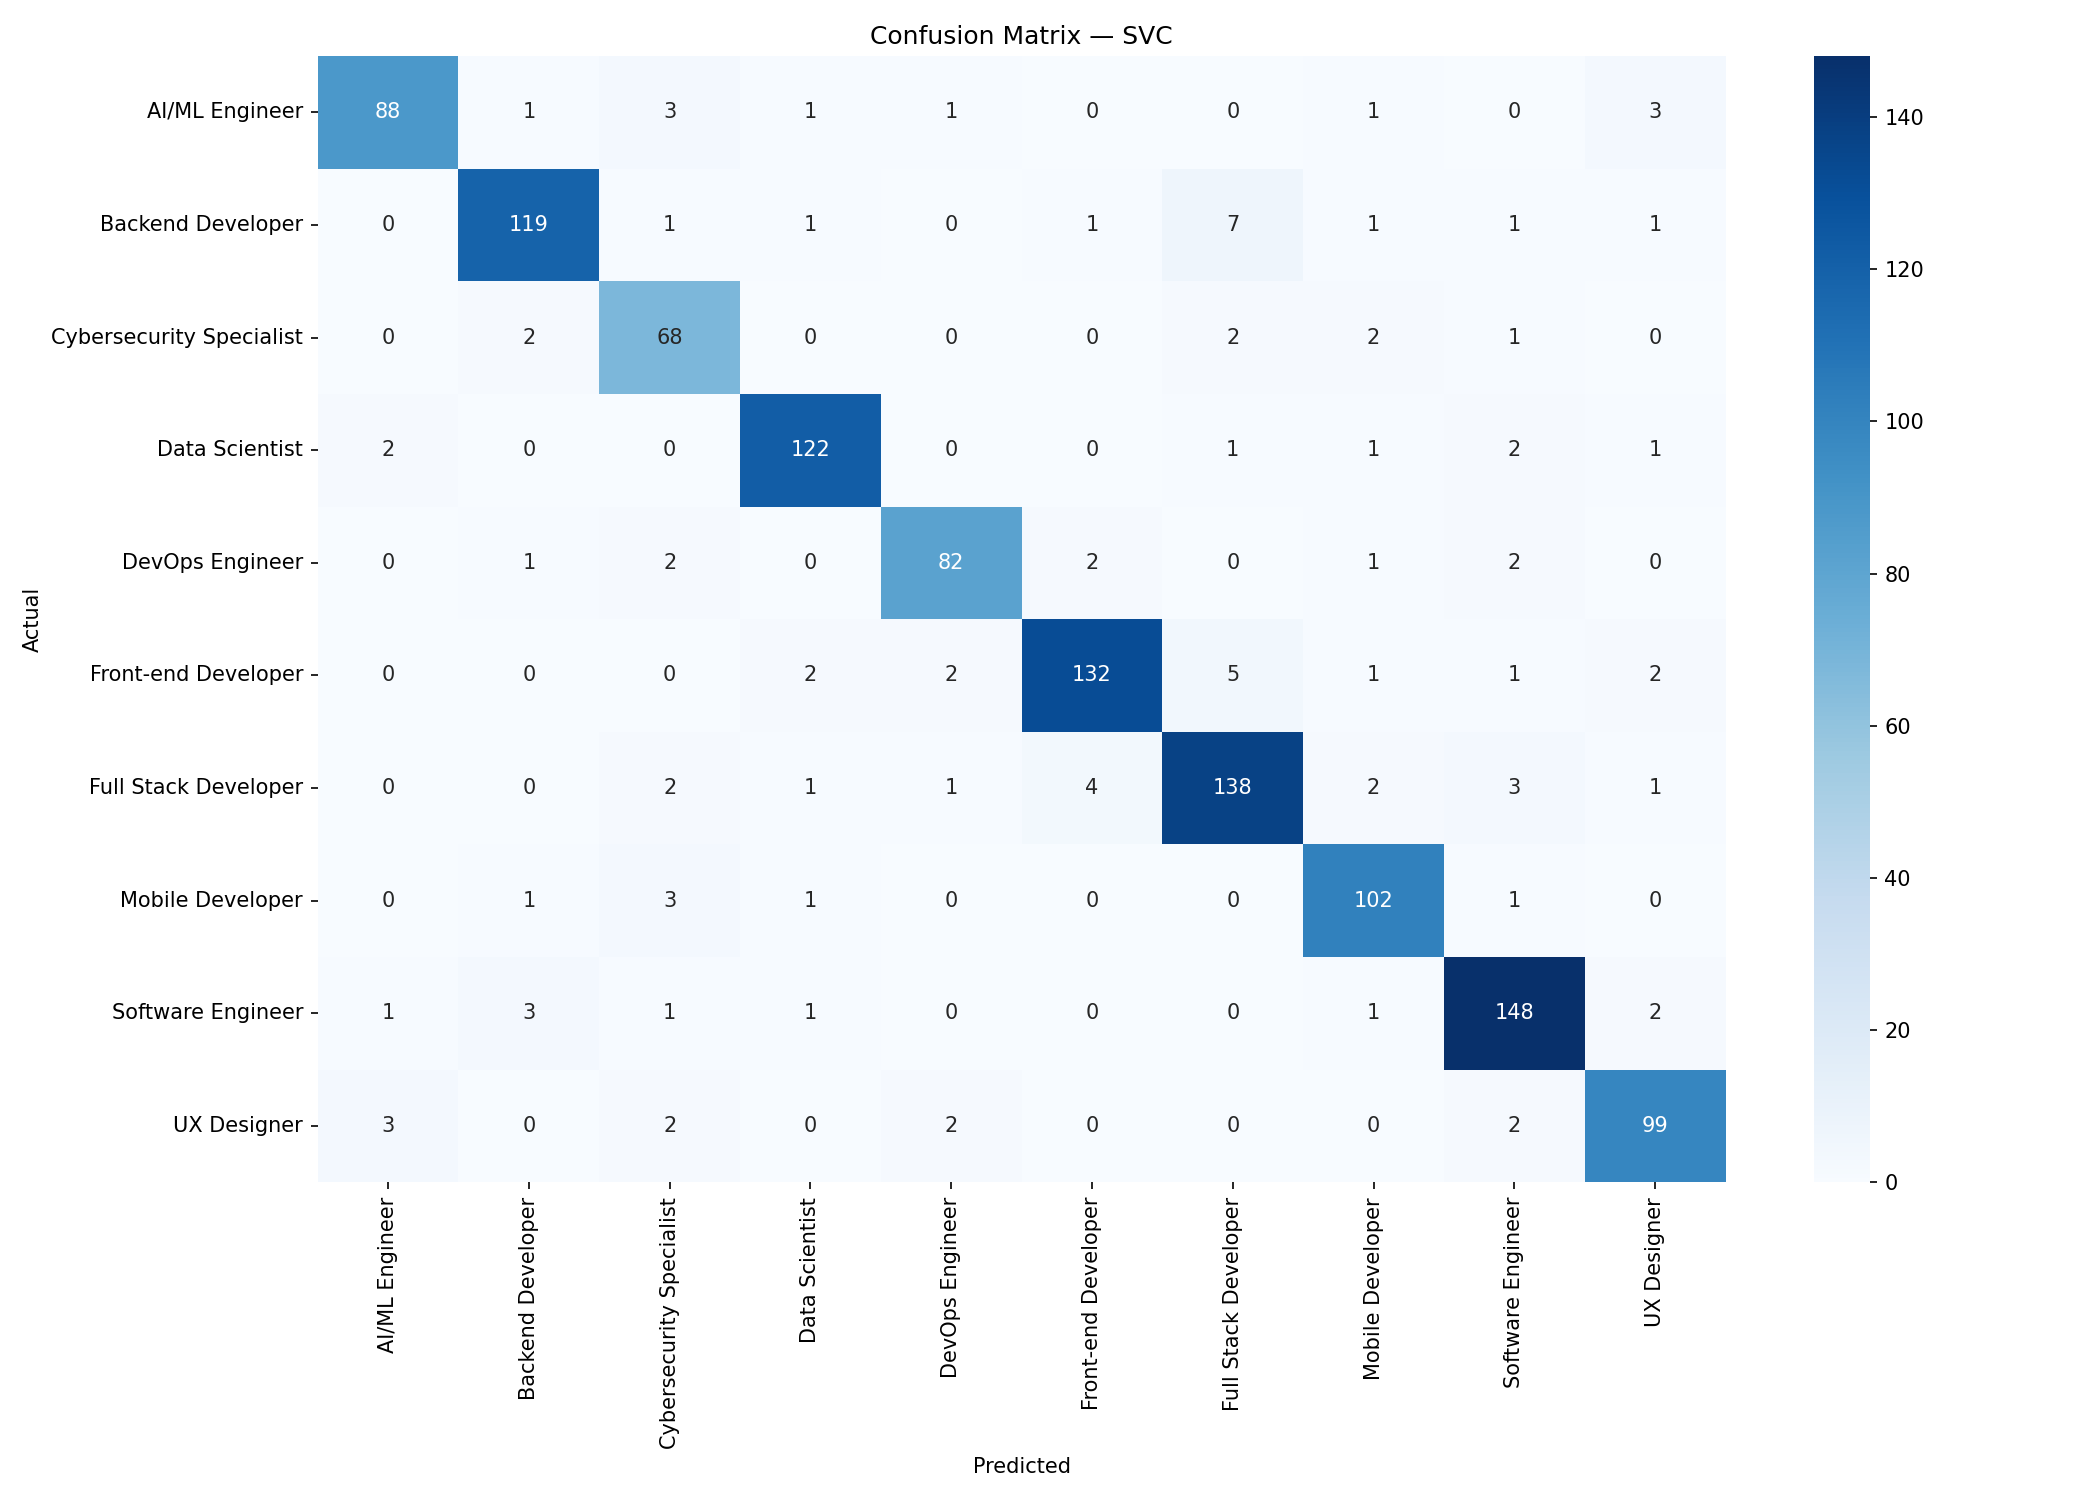

In [12]:
from IPython.display import Image
Image('../data/artifacts/confusion_matrix_svc.png')